<a href="https://colab.research.google.com/github/metel152/Volans-tarkvara/blob/Programmid-graafikute-jaoks/Hea_tulemus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

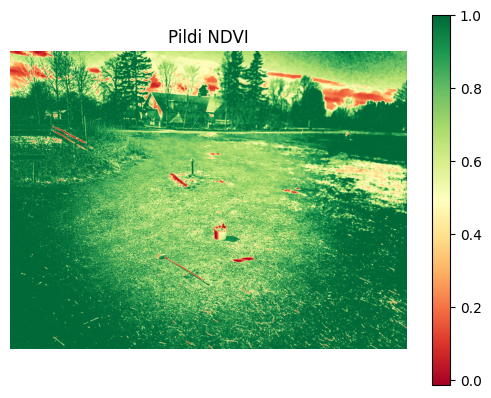

In [10]:
from google.colab import drive


import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- 1. Pildi laadimine (SINU KUJU SÄILIB) ---
path = '/content/drive/MyDrive/Volans_camera/test21.jpg'
pilt = cv2.imread(path)

if pilt is None:
    raise ValueError("Pilti ei leitud – kontrolli failiteed")

# --- 2. Kanalid (NRG / false-color eeldus) ---
# OpenCV = BGR
NIR = pilt[:, :, 2].astype(float)   # punane kanal = NIR
RED = pilt[:, :, 1].astype(float)   # roheline kanal = RED

# --- 3. NDVI (MUUTMATA LOOGIKA) ---
ndvi = (NIR - RED) / (NIR + RED + 1e-10)

# --- 4. NDVI põhine klassifikatsioon ---
result = np.zeros_like(pilt)

# taimkate (Maa-ameti ortofoto loogika: kõrge NDVI = rohelus)
vegetation = ndvi > 0.1

# muu (hooned, teed, pinnas)
non_vegetation = ndvi <= 0.1

# --- 5. Värvimine ---
# Taimed = punane
result[vegetation] = [0, 0, 255]      # BGR

# Hooned/maa = roheline
result[non_vegetation] = [0, 255, 0]  # BGR

# --- 6. Kuvamine (nagu ortofoto visualiseerimine) ---
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar()
plt.title("Pildi NDVI")
plt.axis('off')
plt.show()